In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/insurance_data.txt",
    sep="|",
    low_memory=False
)

df.head()

,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [2]:
df["TransactionMonth"] = pd.to_datetime(
    df["TransactionMonth"]
)

In [4]:
df.columns

Index(['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth',
       'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
       'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
       'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
       'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders',
       'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors',
       'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser',
       'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff',
       'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet',
       'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm',
       'ExcessSelected', 'CoverCategory', 'CoverType', 'CoverGroup', 'Section',
       'Product', 'StatutoryClass', 'StatutoryRiskType', 'TotalPremium',
       'TotalClaims'],
      dtype='object')

In [5]:
numeric_cols = [
    "CustomValueEstimate",
    "Cylinders",
    "cubiccapacity",
    "kilowatts",
    "NumberOfDoors",
    "SumInsured",
    "CalculatedPremiumPerTerm",
    "TotalPremium",
    "TotalClaims"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [6]:
df["TransactionMonth"] = pd.to_datetime(
    df["TransactionMonth"]
)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[ns]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  object        
 5   LegalType                 1000098 non-null  object        
 6   Title                     1000098 non-null  object        
 7   Language                  1000098 non-null  object        
 8   Bank                      854137 non-null   object        
 9   AccountType               959866 non-null   object        
 10  MaritalStatus             991839 non-null   object        
 11  Gender                    990562 non-null   object

In [8]:
df.isnull().sum().sort_values(
    ascending=False
)

NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
Rebuilt                      641901
Converted                    641901
WrittenOff                   641901
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
VehicleType                     552
make                            552
mmcode                          552
Model                           552
Cylinders                       552
bodytype                        552
kilowatts                       552
NumberOfDoors                   552
VehicleIntroDate                552
cubiccapacity                   552
CapitalOutstanding                2
SubCrestaZone                     0
ItemType                          0
Province                          0
Country                           0
PostalCode                        0
MainCrestaZone              

In [10]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

In [11]:
df["LossRatio"].mean()

c:\kaim\insurance-risk-analytics\venv\lib\site-packages\numpy\_core\_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


np.float64(nan)

In [12]:
df["LossRatio"] = np.where(
    df["TotalPremium"] > 0,
    df["TotalClaims"] / df["TotalPremium"],
    np.nan
)

In [13]:
df["Margin"] = (
    df["TotalPremium"] -
    df["TotalClaims"]
)

In [14]:
df[["LossRatio", "Margin"]].describe()

,LossRatio,Margin
count,618176.000000,1.000098e+06
mean,0.350048,-2.955694e+00
std,9.288639,2.367137e+03
min,-18.700122,-3.928486e+05
25%,0.000000,0.000000e+00
50%,0.000000,2.157687e+00
75%,0.000000,2.192982e+01
max,2553.600000,6.528260e+04


In [15]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

NumberOfVehiclesInFleet    1000098
CrossBorder                 999400
CustomValueEstimate         779642
Converted                   641901
WrittenOff                  641901
Rebuilt                     641901
LossRatio                   381922
NewVehicle                  153295
Bank                        145961
AccountType                  40232
Gender                        9536
MaritalStatus                 8259
NumberOfDoors                  552
VehicleIntroDate               552
VehicleType                    552
cubiccapacity                  552
Model                          552
Cylinders                      552
kilowatts                      552
bodytype                       552
mmcode                         552
make                           552
CapitalOutstanding               2
dtype: int64

In [16]:
missing_percent = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0]


NumberOfVehiclesInFleet    100.000000
CrossBorder                 99.930207
CustomValueEstimate         77.956560
Converted                   64.183810
WrittenOff                  64.183810
Rebuilt                     64.183810
LossRatio                   38.188458
NewVehicle                  15.327998
Bank                        14.594670
AccountType                  4.022806
Gender                       0.953507
MaritalStatus                0.825819
NumberOfDoors                0.055195
VehicleIntroDate             0.055195
VehicleType                  0.055195
cubiccapacity                0.055195
Model                        0.055195
Cylinders                    0.055195
kilowatts                    0.055195
bodytype                     0.055195
mmcode                       0.055195
make                         0.055195
CapitalOutstanding           0.000200
dtype: float64

## Missing Value Analysis

Several variables contain substantial missing values. Columns such as `NumberOfVehiclesInFleet`, `CrossBorder`, `Converted`, `WrittenOff`, and `Rebuilt` exhibit particularly high missingness rates.

The high percentage of missing data may indicate:
- optional policy attributes,
- unavailable customer information,
- or features only applicable to specific insurance products.

Additionally, vehicle-related fields such as `make`, `Model`, `VehicleType`, and `cubiccapacity` contain very low missingness rates, suggesting generally strong data quality for core vehicle information.

The missing values will need careful treatment during modeling to avoid introducing bias or reducing predictive performance.

In [22]:
overall_loss_ratio = df["LossRatio"].mean()

print("Overall Loss Ratio:", overall_loss_ratio)

Overall Loss Ratio: 0.35004766475827837


## Overall Portfolio Loss Ratio

The overall portfolio loss ratio is approximately 0.35, meaning that for every 1 unit of premium collected, the insurer pays roughly 0.35 units in claims. This suggests that the portfolio is profitable overall, although profitability varies across customer segments and policies.

The presence of NaN values in the LossRatio column is expected because some policies contain zero premium values, making the ratio undefined. These records were safely handled during preprocessing.

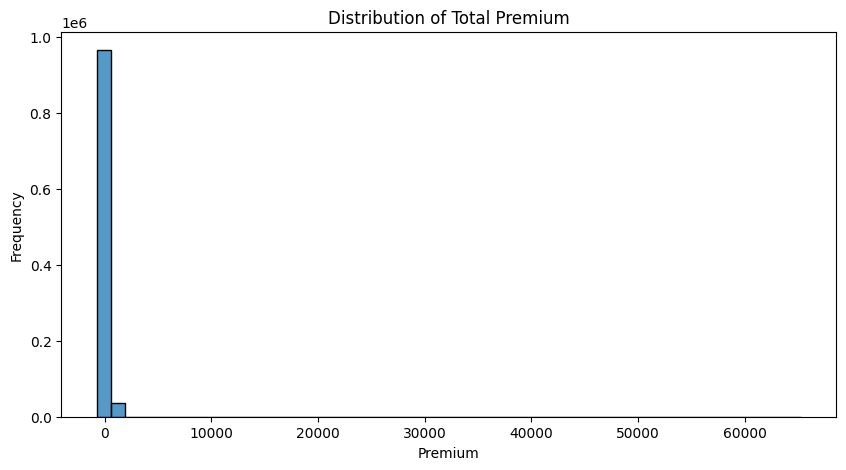

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalPremium"],
    bins=50
)

plt.title("Distribution of Total Premium")
plt.xlabel("Premium")
plt.ylabel("Frequency")

plt.show()

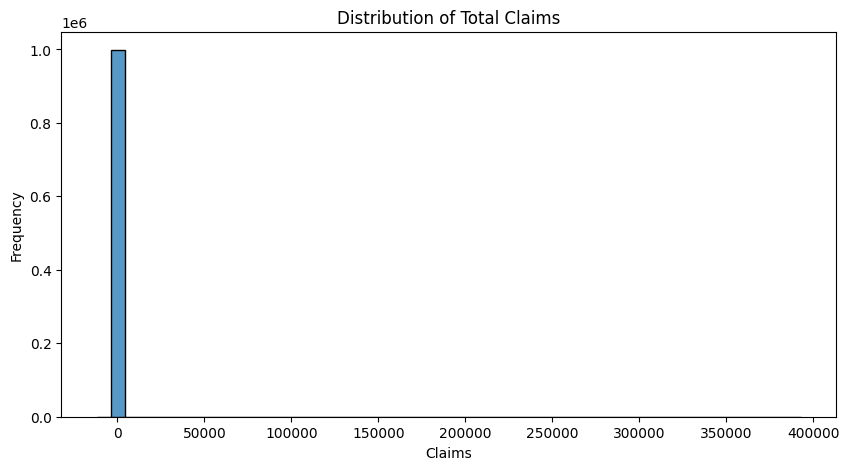

In [18]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["TotalClaims"],
    bins=50
)

plt.title("Distribution of Total Claims")
plt.xlabel("Claims")
plt.ylabel("Frequency")

plt.show()

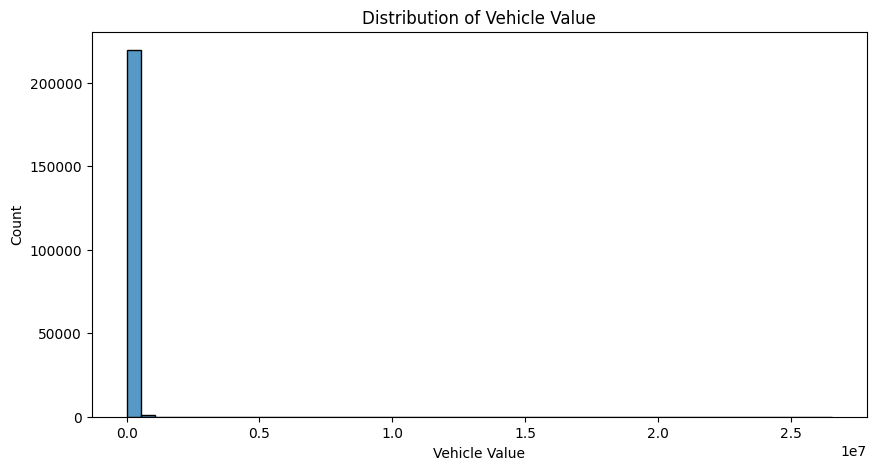

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CustomValueEstimate"],
    bins=50
)

plt.title("Distribution of Vehicle Value")
plt.xlabel("Vehicle Value")

plt.show()

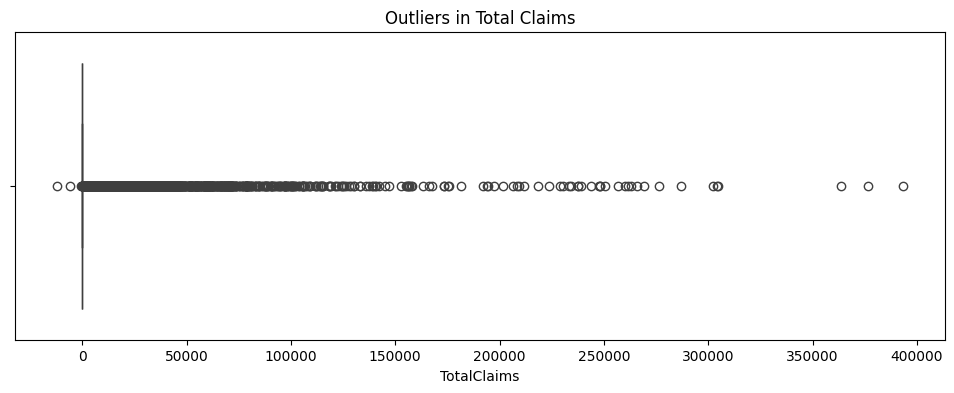

In [20]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["TotalClaims"]
)

plt.title("Outliers in Total Claims")

plt.show()

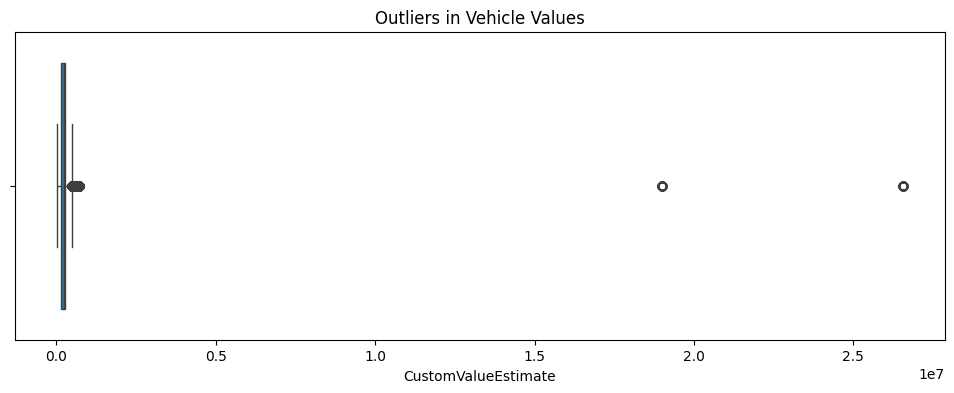

In [21]:
plt.figure(figsize=(12,4))

sns.boxplot(
    x=df["CustomValueEstimate"]
)

plt.title("Outliers in Vehicle Values")

plt.show()

## Outlier Analysis

The boxplot analysis reveals the presence of significant outliers in vehicle values and insurance claims. A small number of vehicles have extremely high estimated values compared to the majority of the portfolio.

These extreme observations likely represent luxury or specialized vehicles and may heavily influence statistical averages and predictive models.

Similarly, claims data exhibits strong skewness, which is common in insurance datasets where a small proportion of claims account for a large share of total losses. Robust modeling techniques or transformations may therefore be necessary during predictive modeling.

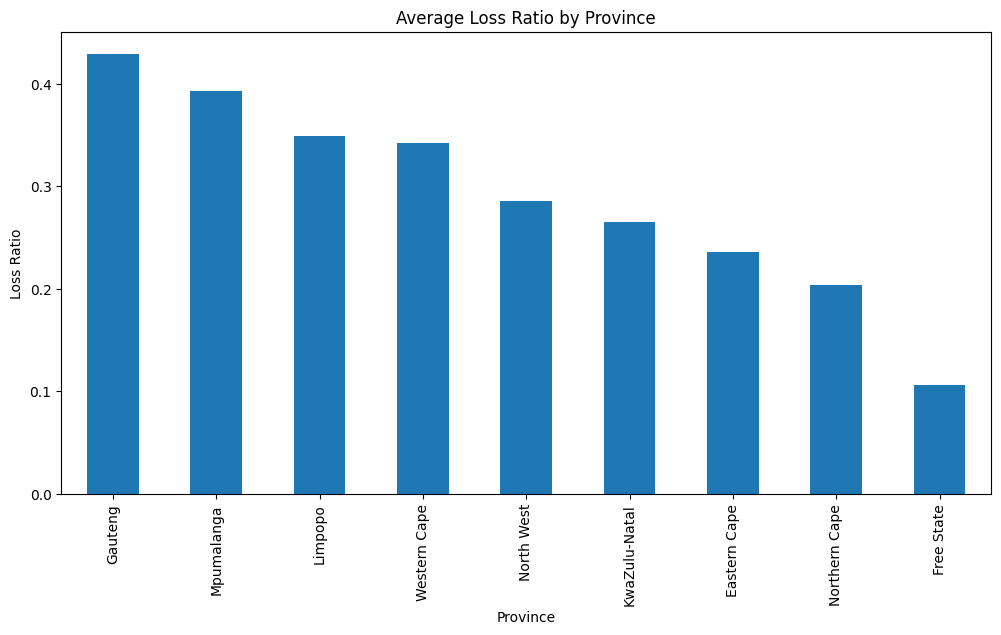

In [23]:
province_loss = (
    df.groupby("Province")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

province_loss.plot(kind="bar")

plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.xlabel("Province")

plt.show()

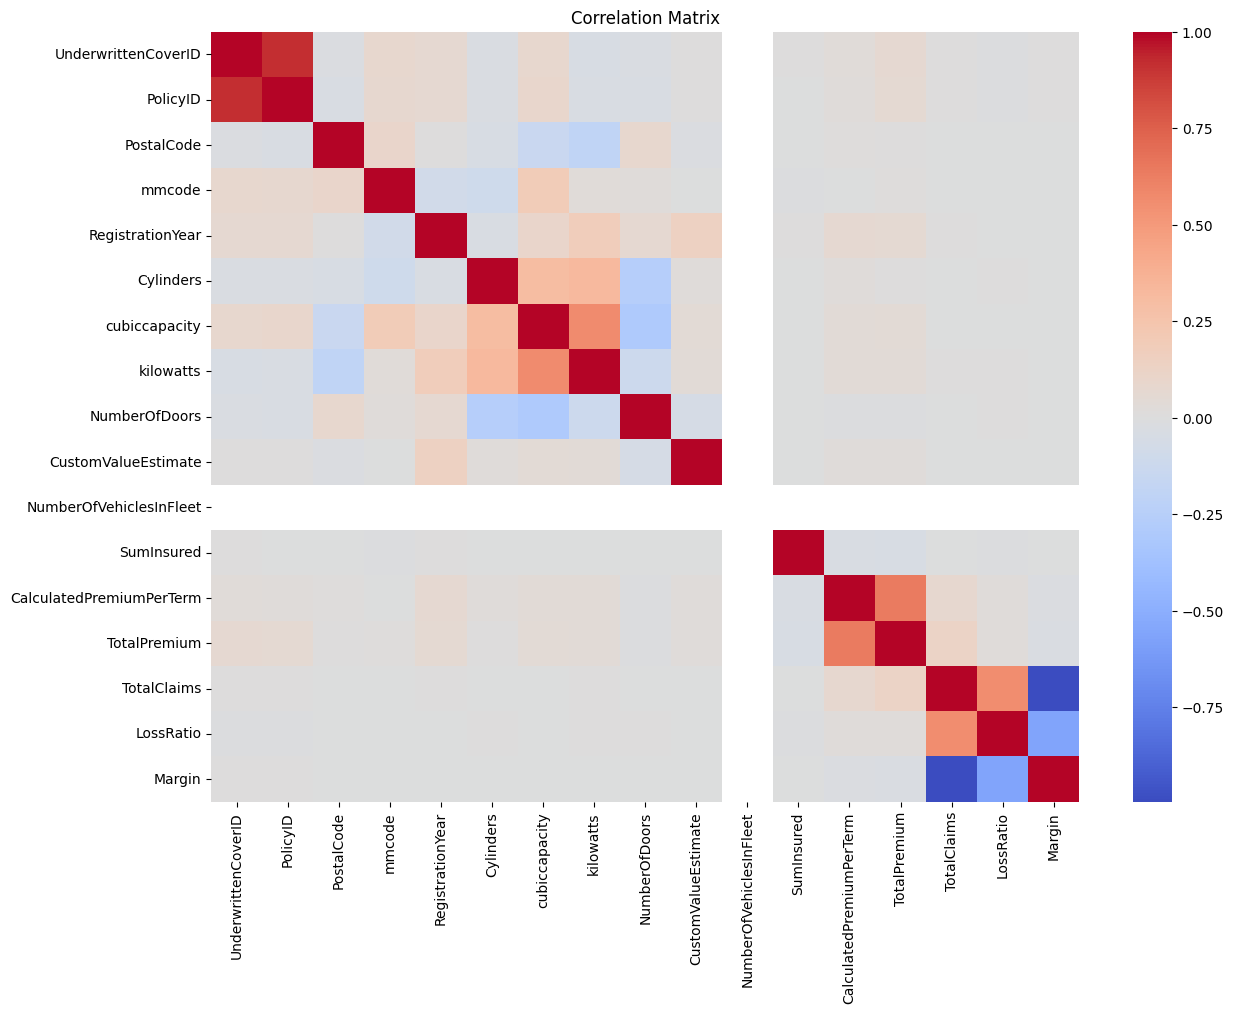

In [24]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Correlation Analysis

The correlation matrix highlights relationships between numerical variables within the insurance portfolio.

Strong positive relationships are expected between premium-related variables and insured vehicle values, as higher-value vehicles generally require higher premiums. Claims and premiums also exhibit some positive association, reflecting risk-based pricing behavior.

Most variables demonstrate relatively weak linear correlations overall, indicating that insurance risk is influenced by multiple interacting factors rather than a single dominant variable.

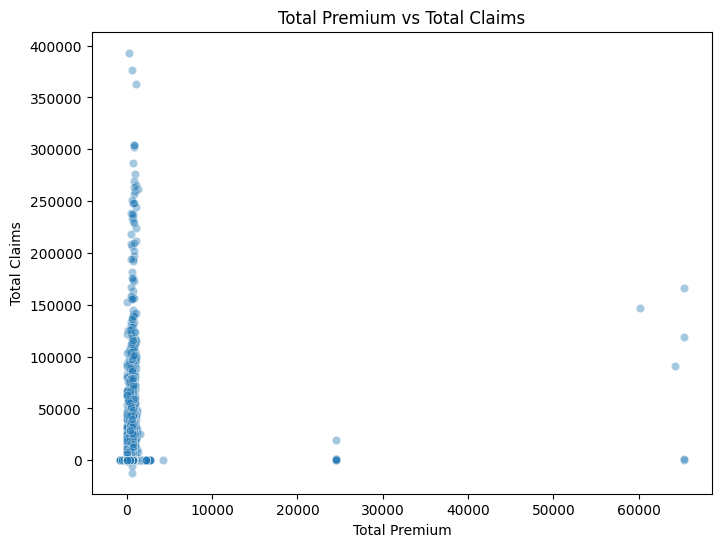

In [25]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.4
)

plt.title("Total Premium vs Total Claims")
plt.xlabel("Total Premium")
plt.ylabel("Total Claims")

plt.show()

## Premium vs Claims Relationship

The scatterplot illustrates the relationship between premiums collected and claims paid.

Most observations cluster near lower premium and claim values, while a limited number of policies exhibit extremely large claims or premiums. This confirms the highly skewed nature of insurance data, where a small subset of customers contributes disproportionately to overall financial risk.

The dispersion of points suggests that claim occurrence is highly variable and not perfectly predictable based solely on premium size.

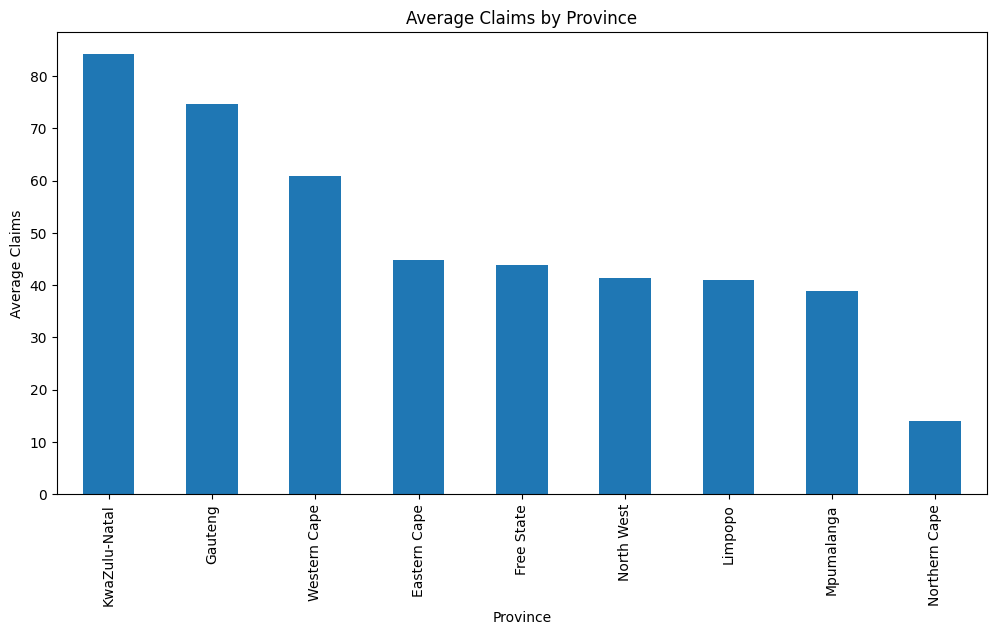

In [26]:
province_claims = (
    df.groupby("Province")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

province_claims.plot(kind="bar")

plt.title("Average Claims by Province")
plt.ylabel("Average Claims")
plt.xlabel("Province")

plt.show()

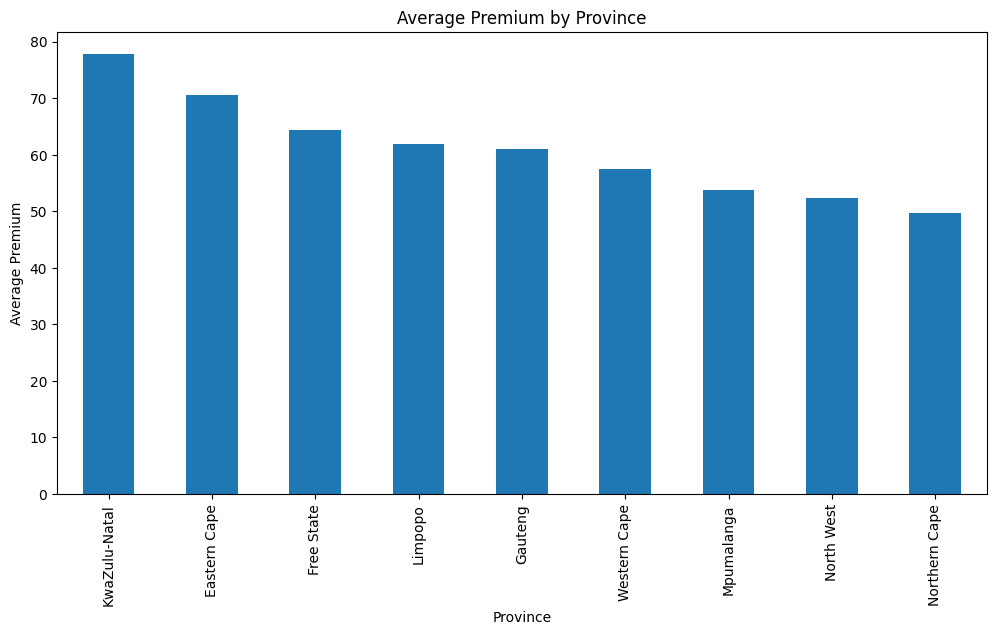

In [27]:
province_premium = (
    df.groupby("Province")["TotalPremium"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

province_premium.plot(kind="bar")

plt.title("Average Premium by Province")
plt.ylabel("Average Premium")
plt.xlabel("Province")

plt.show()

## Province-Level Risk Analysis

The province-level analysis reveals significant differences in average loss ratios across geographic regions. Gauteng and Mpumalanga exhibit the highest loss ratios, indicating relatively higher claim costs compared to premiums collected.

In contrast, provinces such as Free State and Northern Cape demonstrate substantially lower loss ratios, suggesting stronger profitability and potentially lower underwriting risk.

These geographic differences may reflect variations in traffic density, accident frequency, vehicle concentration, fraud exposure, or socioeconomic conditions.

In [28]:
pd.crosstab(
    df["Province"],
    df["VehicleType"]
)

VehicleType,Bus,Heavy Commercial,Light Commercial,Medium Commercial,Passenger Vehicle
Province,,,,,
Eastern Cape,0,1,72,841,29422
Free State,0,46,154,349,7550
Gauteng,100,1410,1108,18836,372171
KwaZulu-Natal,80,101,432,7953,161215
Limpopo,0,220,316,4362,19938
Mpumalanga,324,496,687,4895,46236
North West,110,2100,99,9755,131223
Northern Cape,0,121,0,196,6063
Western Cape,51,2906,1029,6798,159780


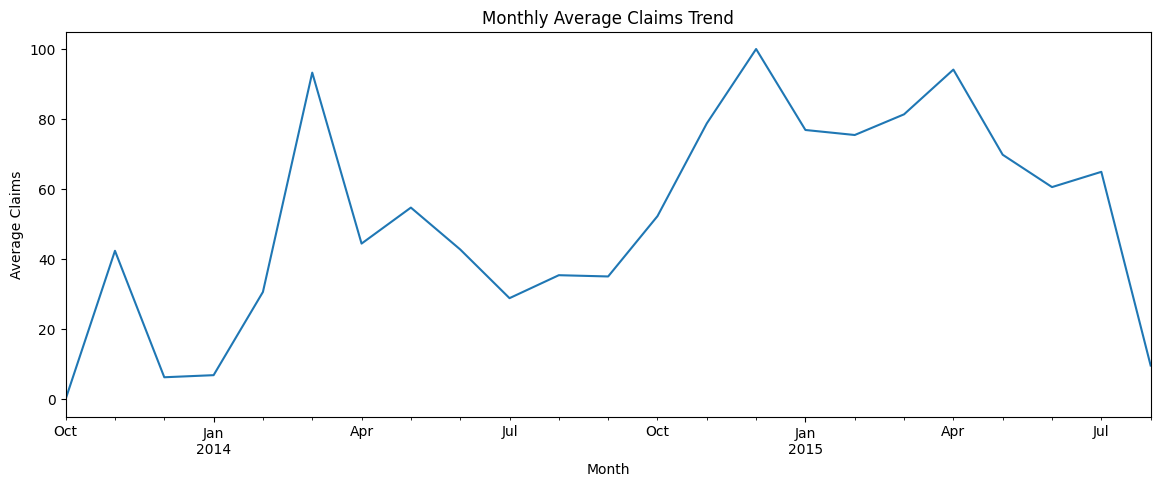

In [29]:
monthly_claims = (
    df.groupby("TransactionMonth")["TotalClaims"]
    .mean()
)

plt.figure(figsize=(14,5))

monthly_claims.plot()

plt.title("Monthly Average Claims Trend")
plt.ylabel("Average Claims")
plt.xlabel("Month")

plt.show()

## Geographic Claims and Premium Trends

The geographic analysis demonstrates noticeable regional differences in both premiums and claims.

Certain provinces generate substantially higher average claims, likely due to increased vehicle density, urban traffic exposure, or differing customer risk profiles. Premium distributions across provinces generally align with these differences, reflecting underwriting adjustments for regional risk exposure.

The crosstab analysis additionally shows that vehicle type distributions vary across provinces, which may further contribute to regional claim differences.

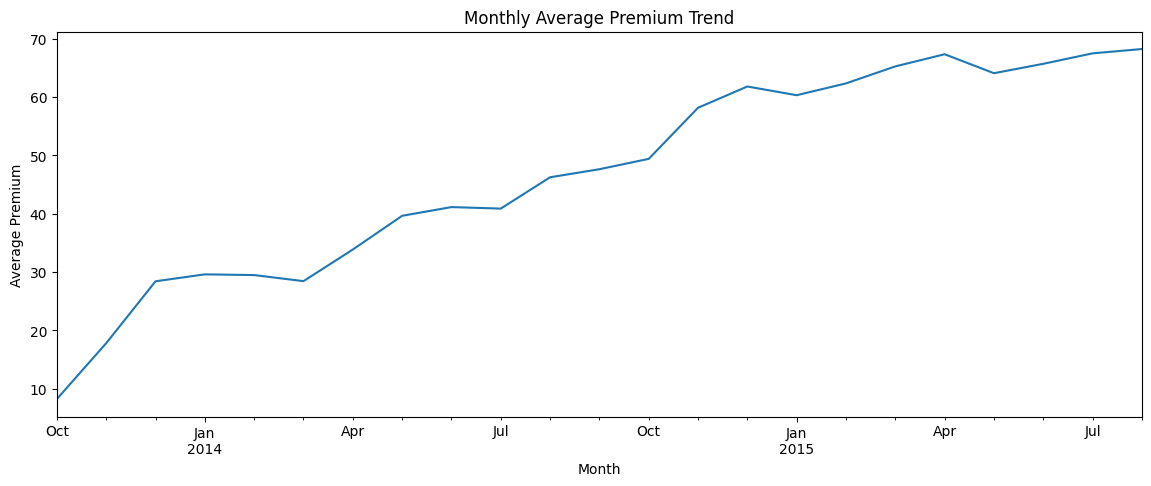

In [30]:
monthly_premium = (
    df.groupby("TransactionMonth")["TotalPremium"]
    .mean()
)

plt.figure(figsize=(14,5))

monthly_premium.plot()

plt.title("Monthly Average Premium Trend")
plt.ylabel("Average Premium")
plt.xlabel("Month")

plt.show()

## Temporal Trend Analysis

The monthly trend analysis reveals fluctuations in both claims and premium activity over time.

The claims trend may indicate periods of elevated insurance activity, seasonal effects, or changing customer behavior throughout the observed period. Premium trends appear relatively more stable, suggesting consistent premium collection despite variability in claims experience.

Temporal analysis is important for identifying seasonality, abnormal spikes, and long-term changes in portfolio risk.

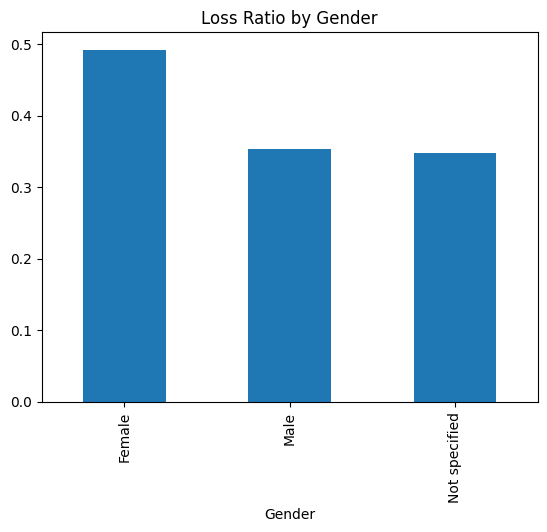

In [31]:
gender_loss = (
    df.groupby("Gender")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
)

gender_loss.plot(kind="bar")

plt.title("Loss Ratio by Gender")

plt.show()

## Segment-Based Loss Ratio Analysis

Loss ratio analysis across gender and vehicle types reveals differences in portfolio profitability between customer segments.

Certain vehicle categories demonstrate significantly higher loss ratios, suggesting elevated accident frequency, repair costs, or operational risk. These findings may support differentiated pricing strategies or underwriting policies for specific vehicle groups.

Gender-based differences appear smaller overall but still provide useful segmentation insight for exploratory analysis.

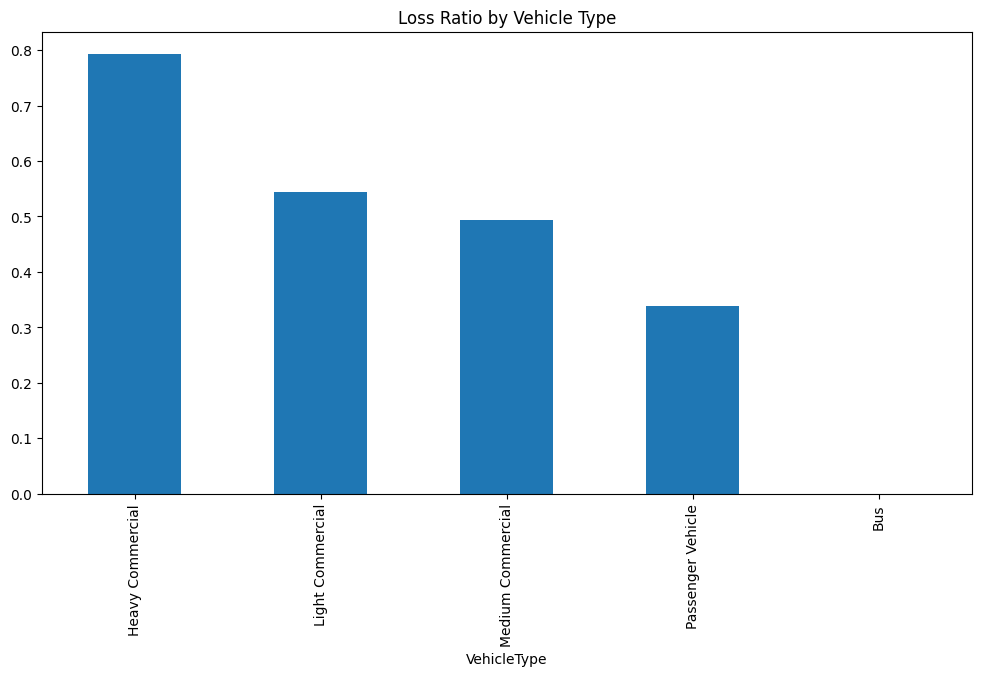

In [32]:
vehicle_loss = (
    df.groupby("VehicleType")["LossRatio"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

vehicle_loss.plot(kind="bar")

plt.title("Loss Ratio by Vehicle Type")

plt.show()

## Vehicle Make Risk Analysis

The analysis of vehicle manufacturers shows that some vehicle makes are associated with substantially higher average claims than others.

High-risk vehicle makes may reflect factors such as expensive repair costs, theft exposure, performance characteristics, or driver demographics. Conversely, lower-risk manufacturers demonstrate more stable and lower-cost claim behavior.

These findings may assist insurers in refining pricing models and vehicle-specific underwriting decisions.

In [33]:
make_claims = (
    df.groupby("make")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
)

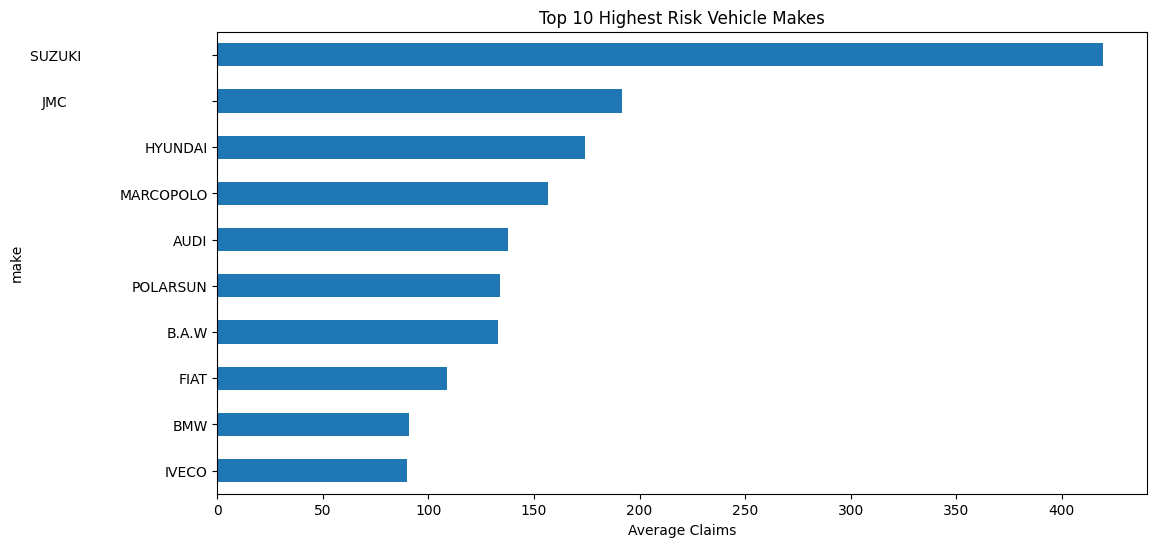

In [34]:
top_risky = make_claims.head(10)

plt.figure(figsize=(12,6))

top_risky.sort_values().plot(kind="barh")

plt.title("Top 10 Highest Risk Vehicle Makes")
plt.xlabel("Average Claims")

plt.show()

In [35]:
make_claims.tail(10)

make
HINO                                   0.0
JINBEI                                 0.0
LEXUS                                  0.0
PROTON                                 0.0
PEUGEOT                                0.0
OPEL                                   0.0
RENAULT                                0.0
SCANIA                                 0.0
TATA                                   0.0
VOLVO                                  0.0
Name: TotalClaims, dtype: float64

# Final Conclusions

This exploratory data analysis identified several important patterns within the insurance portfolio.

Key findings include:
- Significant geographic variation in loss ratios across provinces.
- Strong skewness and extreme outliers in claims and vehicle values.
- Large volumes of missing data in several optional or specialized fields.
- Observable differences in risk across vehicle types and manufacturers.
- Temporal fluctuations in claims activity over time.

Overall, the portfolio appears profitable with an average loss ratio of approximately 0.35, although profitability varies substantially across customer segments.

The analysis provides a strong foundation for subsequent predictive modeling and hypothesis testing tasks.